In [1]:
# ============================================================
# Homework Reflections 1–4
# Cleaned Full Supporting Code
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from scipy.stats import skew
from collections import Counter


In [2]:
# ============================================================
# WEEK 1 HOMEWORK
# Linear Regression
# ============================================================

df_w1_1 = pd.read_csv("homework_1.1.csv")

print(df_w1_1.head())
print(df_w1_1.columns)

X = df_w1_1[["X1", "X2", "X3"]]
y = df_w1_1["Y"]

X = sm.add_constant(X)

model_w1_full = sm.OLS(y, X).fit()

print(model_w1_full.summary())


         X1        X2        X3          Y
0 -0.440646 -0.390227  0.156718  -0.877671
1 -3.810099 -1.304665 -1.105117 -10.130388
2 -1.425451 -0.340049  1.115908   0.284068
3 -1.325750  0.161906 -0.254670  -1.994344
4  3.120263  1.487343 -1.164839   2.030030
Index(['X1', 'X2', 'X3', 'Y'], dtype='str')
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 3.543e+04
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:10:06   Log-Likelihood:                -727.62
No. Observations:                1000   AIC:                             1463.
Df Residuals:                     996   BIC:                             1483.
Df Model:                           3                             

In [3]:
# ------------------------------------------------------------
# Simple regressions for X1, X2, and X3
# ------------------------------------------------------------

X1_only = sm.add_constant(df_w1_1["X1"])
model_x1 = sm.OLS(df_w1_1["Y"], X1_only).fit()
print(model_x1.summary())

X2_only = sm.add_constant(df_w1_1["X2"])
model_x2 = sm.OLS(df_w1_1["Y"], X2_only).fit()
print(model_x2.summary())

X3_only = sm.add_constant(df_w1_1["X3"])
model_x3 = sm.OLS(df_w1_1["Y"], X3_only).fit()
print(model_x3.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     1512.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):          4.81e-202
Time:                        17:10:19   Log-Likelihood:                -2606.3
No. Observations:                1000   AIC:                             5217.
Df Residuals:                     998   BIC:                             5226.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1945      0.104      1.874      0.0

In [4]:
# ============================================================
# WEEK 1 HOMEWORK
# Nearest Neighbor Matching
# ============================================================

df_w1_2 = pd.read_csv("homework_1.2.csv")

print(df_w1_2.head())

treated_w1 = df_w1_2[df_w1_2["X"] == 1].copy()
control_w1 = df_w1_2[df_w1_2["X"] == 0].copy()

Z_treated_w1 = treated_w1[["Z"]]
Z_control_w1 = control_w1[["Z"]]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(Z_control_w1)

distances, indices = nn.kneighbors(Z_treated_w1)

matched_controls_w1 = control_w1.iloc[indices.flatten()].copy()

matching_results = treated_w1.copy()
matching_results["matched_control_index"] = matched_controls_w1.index.values
matching_results["distance"] = distances.flatten()

print(matched_controls_w1.head())
print(matching_results.head())

max_distance = matching_results["distance"].max()

treated_mean = treated_w1["Y"].mean()
control_mean = matched_controls_w1["Y"].mean()

nearest_neighbor_effect = treated_mean - control_mean

print("Maximum Match Distance:", max_distance)
print("Nearest Neighbor Treatment Effect:", nearest_neighbor_effect)


   X         Y         Z
0  0  0.548814  0.548814
1  1  1.215189  0.715189
2  0  0.602763  0.602763
3  0  0.544883  0.544883
4  0  0.423655  0.423655
    X         Y         Z
93  0  0.716327  0.716327
56  0  0.653108  0.653108
41  0  0.437032  0.437032
18  0  0.778157  0.778157
18  0  0.778157  0.778157
   X         Y         Z  matched_control_index  distance
1  1  1.215189  0.715189                     93  0.001138
5  1  1.145894  0.645894                     56  0.007214
6  1  0.937587  0.437587                     41  0.000555
7  1  1.391773  0.891773                     18  0.113616
8  1  1.463663  0.963663                     18  0.185506
Maximum Match Distance: 0.2102170871093757
Nearest Neighbor Treatment Effect: 0.5433600652185839


In [5]:
# ============================================================
# WEEK 1 HOMEWORK
# Radius Neighbors Matching
# ============================================================

df_w1_2_radius = pd.read_csv("homework_1.2.csv")

treated_radius = df_w1_2_radius[df_w1_2_radius["X"] == 1].copy()
control_radius = df_w1_2_radius[df_w1_2_radius["X"] == 0].copy()

Z_treated_radius = treated_radius[["Z"]]
Z_control_radius = control_radius[["Z"]]

radius_nn = NearestNeighbors(radius=0.2)
radius_nn.fit(Z_control_radius)

radius_distances, radius_indices = radius_nn.radius_neighbors(Z_treated_radius)

print(radius_indices[0])
print(radius_distances[0])

total_matches = sum(len(i) for i in radius_indices)

print("Total Matches:", total_matches)


[ 0  1  2  4  5  9 12 17 20 21 25 31 35 41 43 45 48]
[0.16637586 0.11242599 0.17030618 0.18629445 0.14714481 0.06296738
 0.19334104 0.09825537 0.04842265 0.0445515  0.06208104 0.05885978
 0.02407421 0.14858791 0.19194131 0.13924287 0.00113784]
Total Matches: 737


In [6]:
# ------------------------------------------------------------
# Create matched dataset
# ------------------------------------------------------------

matched_rows = []

for neighbors in radius_indices:
    for neighbor in neighbors:
        matched_rows.append(control_radius.iloc[neighbor])

matched_controls_radius = pd.DataFrame(matched_rows)

print(matched_controls_radius.head())


      X         Y         Z
0   0.0  0.548814  0.548814
2   0.0  0.602763  0.602763
3   0.0  0.544883  0.544883
11  0.0  0.528895  0.528895
12  0.0  0.568045  0.568045


In [7]:
# ------------------------------------------------------------
# Count duplicate matches
# ------------------------------------------------------------

all_matches = []

for neighbor_list in radius_indices:
    all_matches.extend(neighbor_list)

counts = Counter(all_matches)

duplicates = sum(
    count - 1
    for count in counts.values()
    if count > 1
)

print("Duplicate Matches:", duplicates)


Duplicate Matches: 685


In [8]:
# ------------------------------------------------------------
# Estimate treatment effect using radius-neighbor groups
# ------------------------------------------------------------

neighbor_group_means = []

for neighbor_indices in radius_indices:

    if len(neighbor_indices) == 0:
        continue

    group_mean = control_radius.iloc[neighbor_indices]["Y"].mean()
    neighbor_group_means.append(group_mean)

avg_control_y = np.mean(neighbor_group_means)
avg_treated_y = treated_radius["Y"].mean()

radius_effect = avg_treated_y - avg_control_y

print("Radius Neighbor Treatment Effect:", radius_effect)


Radius Neighbor Treatment Effect: 0.5844124774246181


In [9]:
# ------------------------------------------------------------
# Reflection 1 Additional Matching Method:
# K-Nearest-Neighbor Matching
# ------------------------------------------------------------

df_w1_2_knn = pd.read_csv("homework_1.2.csv")

treated_knn = df_w1_2_knn[df_w1_2_knn["X"] == 1].copy()
control_knn = df_w1_2_knn[df_w1_2_knn["X"] == 0].copy()

k = 3

knn = NearestNeighbors(n_neighbors=k)
knn.fit(control_knn[["Z"]])

k_distances, k_indices = knn.kneighbors(treated_knn[["Z"]])

control_group_means = []

for neighbor_indices in k_indices:
    group_mean = control_knn.iloc[neighbor_indices]["Y"].mean()
    control_group_means.append(group_mean)

k_match_effect = treated_knn["Y"].mean() - np.mean(control_group_means)

print("K-Nearest-Neighbor Treatment Effect:", k_match_effect)



K-Nearest-Neighbor Treatment Effect: 0.5577110922254459


In [ ]:
# ============================================================
# WEEK 2 HOMEWORK
# Fixed Effects Regression
# ============================================================

df_w2_1 = pd.read_csv("homework_2.1.csv")
df_w2_2 = pd.read_csv("homework_2.2.csv")

df_long = df_w2_1.melt(
    id_vars="time",
    value_vars=["G1", "G2", "G3"],
    var_name="group",
    value_name="outcome"
)

print(df_long.head())

fixed_effects_model = smf.ols(
    "outcome ~ time + C(group)",
    data=df_long
).fit()

print(fixed_effects_model.summary())
print(fixed_effects_model.params)


   time group   outcome
0     0    G1  0.882026
1     1    G1  0.210079
2     2    G1  0.509369
3     3    G1  1.150447
4     4    G1  0.973779
                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     44.55
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           8.72e-24
Time:                        17:11:23   Log-Likelihood:                -216.89
No. Observations:                 300   AIC:                             441.8
Df Residuals:                     296   BIC:                             456.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0

In [11]:
# ============================================================
# WEEK 2 HOMEWORK
# Treatment Effect and Bootstrap
# ============================================================

treated_mean = df_w2_2[df_w2_2["X"] == 1]["Y"].mean()
untreated_mean = df_w2_2[df_w2_2["X"] == 0]["Y"].mean()

effect1 = treated_mean - untreated_mean

print("Simple Treatment Effect:", effect1)


Simple Treatment Effect: 2.9207172647231907


In [12]:
# ------------------------------------------------------------
# Bootstrap the simple treatment effect
# ------------------------------------------------------------

np.random.seed(42)

effects = []

for i in range(10000):

    sample = df_w2_2.sample(
        n=len(df_w2_2),
        replace=True
    )

    effect = (
        sample[sample["X"] == 1]["Y"].mean()
        -
        sample[sample["X"] == 0]["Y"].mean()
    )

    effects.append(effect)

bootstrap_variance = np.var(effects, ddof=1)

print("Bootstrap Variance of Treatment Effects:", bootstrap_variance)


Bootstrap Variance of Treatment Effects: 0.03255543091954204


In [13]:
# ------------------------------------------------------------
# Bootstrap the regression coefficient
# ------------------------------------------------------------

effects2 = []

for i in range(10000):

    sample = df_w2_2.sample(
        n=len(df_w2_2),
        replace=True
    )

    X_boot = sm.add_constant(sample["X"])
    y_boot = sample["Y"]

    model_boot = sm.OLS(y_boot, X_boot).fit()

    effects2.append(model_boot.params["X"])

effect_skewness = skew(effects2)

print("Skewness of Bootstrapped Regression Coefficients:", effect_skewness)

Skewness of Bootstrapped Regression Coefficients: 0.08210989734046856


In [ ]:
# ============================================================
# REFLECTION 2
# Bootstrap Simulation Using Pareto Distribution
# ============================================================

np.random.seed(42)

sample_sizes = [100, 500, 1000, 5000]
n_bootstrap = 5000
pareto_shape = 3

for n in sample_sizes:

    pareto_data = np.random.pareto(
        a=pareto_shape,
        size=n
    )

    bootstrap_means = []

    for _ in range(n_bootstrap):

        sample = np.random.choice(
            pareto_data,
            size=n,
            replace=True
        )

        bootstrap_means.append(sample.mean())

    variance_of_means = np.var(
        bootstrap_means,
        ddof=1
    )

    print("Sample Size:", n)
    print("Variance of Bootstrap Means:", variance_of_means)
    print()


Sample Size: 100
Variance of Bootstrap Means: 0.0031503782728409956

Sample Size: 500
Variance of Bootstrap Means: 0.0008887220309986099

Sample Size: 1000
Variance of Bootstrap Means: 0.0007007022944835306

Sample Size: 5000
Variance of Bootstrap Means: 0.00017507519802212727



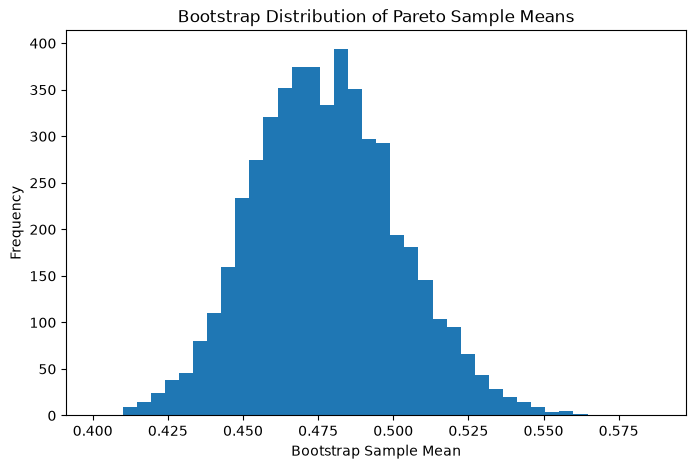

In [ ]:
# ------------------------------------------------------------
# Plot bootstrap distribution for one Pareto sample size
# ------------------------------------------------------------

np.random.seed(42)

n = 1000

pareto_data = np.random.pareto(
    a=pareto_shape,
    size=n
)

bootstrap_means = []

for _ in range(n_bootstrap):

    sample = np.random.choice(
        pareto_data,
        size=n,
        replace=True
    )

    bootstrap_means.append(sample.mean())

plt.figure(figsize=(8, 5))
plt.hist(bootstrap_means, bins=40)
plt.xlabel("Bootstrap Sample Mean")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Pareto Sample Means")
plt.show()

In [16]:
# ============================================================
# WEEK 3 HOMEWORK
# Event Study
# ============================================================

df_w3_1 = pd.read_csv("homework_3.1.csv")

df_w3_1["event"] = (df_w3_1["time"] >= 50).astype(int)
df_w3_1["time_after"] = df_w3_1["time"] * df_w3_1["event"]


In [17]:
# ------------------------------------------------------------
# Test for discontinuity in value only
# ------------------------------------------------------------

model_q1 = smf.ols(
    "value1 ~ time + event",
    data=df_w3_1
).fit()

print(model_q1.summary())


                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     90.57
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           6.48e-23
Time:                        17:13:08   Log-Likelihood:                -160.63
No. Observations:                 100   AIC:                             327.3
Df Residuals:                      97   BIC:                             335.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4439      0.271     -1.640      0.1

In [18]:
# ------------------------------------------------------------
# Repeat value-only discontinuity model
# ------------------------------------------------------------

for value_col in ["value1", "value2", "value3"]:

    value_model = smf.ols(
        f"{value_col} ~ time + event",
        data=df_w3_1
    ).fit()

    print(value_col)
    print(value_model.summary())



value1
                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     90.57
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           6.48e-23
Time:                        17:13:17   Log-Likelihood:                -160.63
No. Observations:                 100   AIC:                             327.3
Df Residuals:                      97   BIC:                             335.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4439      0.271     -1.640  

In [19]:
# ------------------------------------------------------------
# Test for discontinuity in slope
# ------------------------------------------------------------

model_q2 = smf.ols(
    "value1 ~ time + event + time_after",
    data=df_w3_1
).fit()

print(model_q2.summary())


                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     120.2
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           2.18e-32
Time:                        17:13:25   Log-Likelihood:                -135.33
No. Observations:                 100   AIC:                             278.7
Df Residuals:                      96   BIC:                             289.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8464      0.266      3.178      0.0

In [20]:
# ------------------------------------------------------------
# Repeat slope-change model
# ------------------------------------------------------------

for value_col in ["value1", "value2", "value3"]:

    slope_model = smf.ols(
        f"{value_col} ~ time + event + time_after",
        data=df_w3_1
    ).fit()

    print(value_col)
    print(slope_model.summary())


value1
                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     120.2
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           2.18e-32
Time:                        17:13:39   Log-Likelihood:                -135.33
No. Observations:                 100   AIC:                             278.7
Df Residuals:                      96   BIC:                             289.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8464      0.266      3.178  

In [21]:
# ------------------------------------------------------------
# Reflection 3:
# Test for change in the second derivative
# ------------------------------------------------------------

df_w3_1["time_sq"] = df_w3_1["time"] ** 2
df_w3_1["time_sq_after"] = df_w3_1["time_sq"] * df_w3_1["event"]

for value_col in ["value1", "value2", "value3"]:

    second_derivative_model = smf.ols(
        f"{value_col} ~ time + time_sq + event + time_after + time_sq_after",
        data=df_w3_1
    ).fit()

    print("Second Derivative Test for:", value_col)
    print(second_derivative_model.summary())


Second Derivative Test for: value1
                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     71.17
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           1.97e-30
Time:                        17:13:48   Log-Likelihood:                -135.02
No. Observations:                 100   AIC:                             282.0
Df Residuals:                      94   BIC:                             297.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept  

In [22]:
# ============================================================
# WEEK 3 HOMEWORK
# Difference-in-Differences Dataset A
# ============================================================

df_w3_2a = pd.read_csv("homework_3.2.a.csv")

print(df_w3_2a.head())
print(df_w3_2a.columns)

df_w3_2a["did"] = df_w3_2a["group1"] * df_w3_2a["time1"]

did_model_a = smf.ols(
    "outcome1 ~ group1 + time1 + did",
    data=df_w3_2a
).fit()

print(did_model_a.summary())


   group1  time1  outcome1
0       0      0  0.882026
1       0      1  1.600079
2       0      0  0.489369
3       0      1  2.520447
4       0      0  0.933779
Index(['group1', 'time1', 'outcome1'], dtype='str')
                            OLS Regression Results                            
Dep. Variable:               outcome1   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     2964.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:13:58   Log-Likelihood:                -712.28
No. Observations:                1000   AIC:                             1433.
Df Residuals:                     996   BIC:                             1452.
Df Model:                           3                                         
Covariance Type:            nonrobust                                      

In [23]:
# ============================================================
# WEEK 3 HOMEWORK
# Difference-in-Differences Dataset B
# ============================================================

df_w3_2b = pd.read_csv("homework_3.2.b.csv")

print(df_w3_2b.head())
print(df_w3_2b.columns)

df_w3_2b["did"] = df_w3_2b["group2"] * df_w3_2b["time2"]

did_model_b = smf.ols(
    "outcome2 ~ group2 + time2 + did",
    data=df_w3_2b
).fit()

print(did_model_b.summary())


   group2  time2  outcome2
0       0      0  0.667155
1       0      1  2.470969
2       0      0 -0.506778
3       0      1  1.525657
4       0      0  0.273664
Index(['group2', 'time2', 'outcome2'], dtype='str')
                            OLS Regression Results                            
Dep. Variable:               outcome2   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     653.6
Date:                Sat, 20 Jun 2026   Prob (F-statistic):          9.62e-235
Time:                        17:14:08   Log-Likelihood:                -1567.5
No. Observations:                1000   AIC:                             3143.
Df Residuals:                     996   BIC:                             3163.
Df Model:                           3                                         
Covariance Type:            nonrobust                                      

In [ ]:
# ------------------------------------------------------------
# Alternative equivalent formula for Dataset B
# group2 * time2 includes group2, time2, and group2:time2
# ------------------------------------------------------------

did_model_b_alt = smf.ols(
    "outcome2 ~ group2 * time2",
    data=df_w3_2b
).fit()

print(did_model_b_alt.summary())


                            OLS Regression Results                            
Dep. Variable:               outcome2   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     653.6
Date:                Sat, 20 Jun 2026   Prob (F-statistic):          9.62e-235
Time:                        17:14:18   Log-Likelihood:                -1567.5
No. Observations:                1000   AIC:                             3143.
Df Residuals:                     996   BIC:                             3163.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1021      0.073      1.392   

In [25]:
# ------------------------------------------------------------
# Reflection 3:
# Invented DID scenario
# ------------------------------------------------------------

did_data = pd.DataFrame({
    "group": [
        "Treatment",
        "Treatment",
        "Control",
        "Control"
    ],
    "period": [
        "Before",
        "After",
        "Before",
        "After"
    ],
    "outcome": [
        55,
        72,
        58,
        64
    ]
})

did_data["treatment"] = (
    did_data["group"] == "Treatment"
).astype(int)

did_data["after"] = (
    did_data["period"] == "After"
).astype(int)

did_data["did"] = (
    did_data["treatment"]
    *
    did_data["after"]
)

did_model_example = smf.ols(
    "outcome ~ treatment + after + did",
    data=did_data
).fit()

print(did_data)
print(did_model_example.summary())

treatment_change = 72 - 55
control_change = 64 - 58
did_effect = treatment_change - control_change

print("Treatment Group Change:", treatment_change)
print("Control Group Change:", control_change)
print("Difference-in-Differences Effect:", did_effect)


       group  period  outcome  treatment  after  did
0  Treatment  Before       55          1      0    0
1  Treatment   After       72          1      1    1
2    Control  Before       58          0      0    0
3    Control   After       64          0      1    0
                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sat, 20 Jun 2026   Prob (F-statistic):                nan
Time:                        17:14:31   Log-Likelihood:                 118.45
No. Observations:                   4   AIC:                            -228.9
Df Residuals:                       0   BIC:                            -231.4
Df Model:                           3                                         
Covariance Type:        

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


In [26]:
# ============================================================
# WEEK 4 HOMEWORK
# Instrumental Variables
# ============================================================

df_w4_1 = pd.read_csv("homework_4.1.csv")


In [ ]:
# ------------------------------------------------------------
# Method 1: Wald estimator using Z
# ------------------------------------------------------------

y_diff = (
    df_w4_1[df_w4_1["Z"] == 1]["Y"].mean()
    -
    df_w4_1[df_w4_1["Z"] == 0]["Y"].mean()
)

x_diff = (
    df_w4_1[df_w4_1["Z"] == 1]["X"].mean()
    -
    df_w4_1[df_w4_1["Z"] == 0]["X"].mean()
)

effect_1 = y_diff / x_diff

print("Method 1 Effect:", effect_1)

Method 1 Effect: 1.5618587073765746


In [28]:
# ------------------------------------------------------------
# Method 2: Divide W into multiple ranges
# ------------------------------------------------------------

df_w4_1_bins = pd.read_csv("homework_4.1.csv")

df_w4_1_bins["W_bin"] = pd.qcut(
    df_w4_1_bins["W"],
    q=10,
    duplicates="drop"
)

effects = []

for _, group in df_w4_1_bins.groupby("W_bin"):

    if group["Z"].nunique() < 2:
        continue

    y_diff = (
        group[group["Z"] == 1]["Y"].mean()
        -
        group[group["Z"] == 0]["Y"].mean()
    )

    x_diff = (
        group[group["Z"] == 1]["X"].mean()
        -
        group[group["Z"] == 0]["X"].mean()
    )

    if abs(x_diff) > 1e-10:
        effects.append(y_diff / x_diff)

effect_2 = np.mean(effects)

print("Method 2 Effect:", effect_2)


Method 2 Effect: 1.5088963715223709


In [29]:
# ============================================================
# WEEK 4 HOMEWORK
# Regression Discontinuity
# ============================================================

df_a = pd.read_csv("homework_4.2.a.csv")
df_b = pd.read_csv("homework_4.2.b.csv")

print(df_a.head())
print(df_a.columns)

print(df_b.head())
print(df_b.columns)



           X  Y
0  81.822339  1
1  92.487870  0
2  85.372460  0
3  78.828025  0
4  75.807080  1
Index(['X', 'Y'], dtype='str')
          X2  Y2
0  76.643034   1
1  87.743397   1
2  81.639469   1
3  73.740485   0
4  90.480268   1
Index(['X2', 'Y2'], dtype='str')


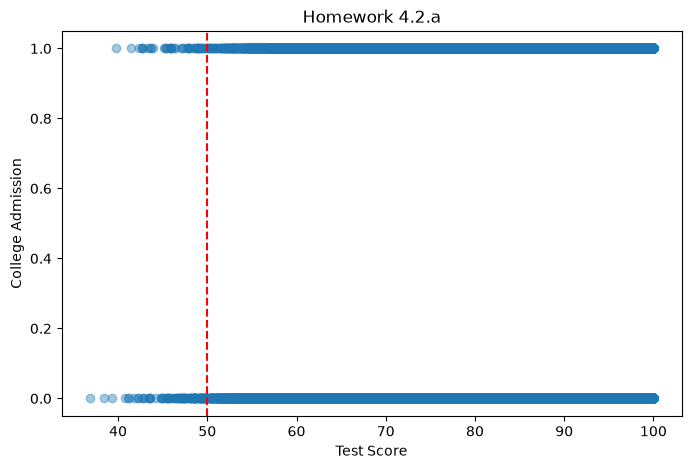

In [ ]:
# ------------------------------------------------------------
# Visualize Dataset A
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(df_a["X"], df_a["Y"], alpha=0.4)
plt.axvline(50, color="red", linestyle="--")
plt.xlabel("Test Score")
plt.ylabel("College Admission")
plt.title("Homework 4.2.a")
plt.show()


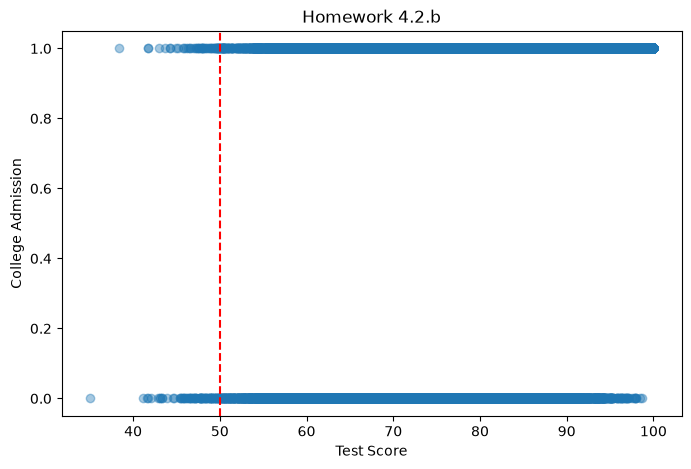

In [ ]:
# ------------------------------------------------------------
# Visualize Dataset B
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(df_b["X2"], df_b["Y2"], alpha=0.4)
plt.axvline(50, color="red", linestyle="--")
plt.xlabel("Test Score")
plt.ylabel("College Admission")
plt.title("Homework 4.2.b")
plt.show()


In [32]:
# ------------------------------------------------------------
# Estimate treatment effect for Dataset A using local means
# ------------------------------------------------------------

cutoff = 50
bandwidth = 10

local_a_50 = df_a[
    (df_a["X"] >= cutoff - bandwidth)
    &
    (df_a["X"] <= cutoff + bandwidth)
].copy()

above_a = local_a_50[local_a_50["X"] >= cutoff]["Y"].mean()
below_a = local_a_50[local_a_50["X"] < cutoff]["Y"].mean()

effect_a = above_a - below_a

print("RDD Effect A:", effect_a)



RDD Effect A: -0.0004179728317659226


In [33]:
# ------------------------------------------------------------
# Estimate treatment effect for Dataset B using local means
# ------------------------------------------------------------

local_b_50 = df_b[
    (df_b["X2"] >= cutoff - bandwidth)
    &
    (df_b["X2"] <= cutoff + bandwidth)
].copy()

above_b = local_b_50[local_b_50["X2"] >= cutoff]["Y2"].mean()
below_b = local_b_50[local_b_50["X2"] < cutoff]["Y2"].mean()

effect_b = above_b - below_b

print("RDD Effect B:", effect_b)


RDD Effect B: 0.09823418481056062


In [34]:
# ------------------------------------------------------------
# RDD regression for Dataset A with cutoff 50
# ------------------------------------------------------------

df_a["treated_50"] = (df_a["X"] >= 50).astype(int)
df_a["running_50"] = df_a["X"] - 50

model_a_50 = smf.ols(
    "Y ~ running_50 + treated_50 + running_50:treated_50",
    data=df_a
).fit()

print(model_a_50.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     2110.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:15:55   Log-Likelihood:                -69063.
No. Observations:              100000   AIC:                         1.381e+05
Df Residuals:                   99996   BIC:                         1.382e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.26

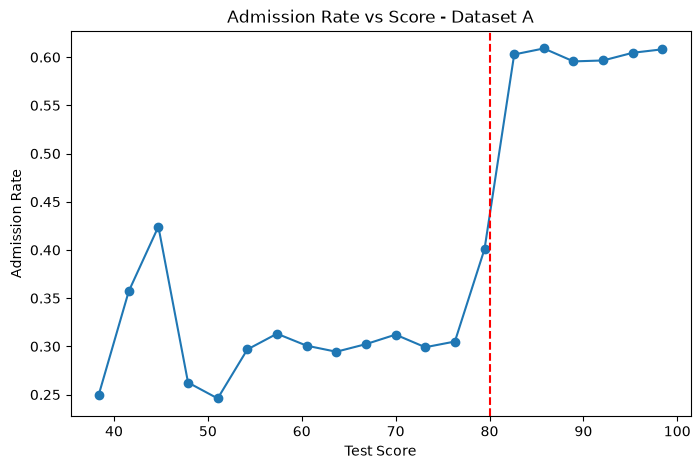

In [35]:
# ------------------------------------------------------------
# Binned admission rate for Dataset A
# ------------------------------------------------------------

df_a["bin_80"] = pd.cut(
    df_a["X"],
    bins=20
)

rates_a = df_a.groupby("bin_80")["Y"].mean()

x_vals_a = [
    interval.mid
    for interval in rates_a.index
]

plt.figure(figsize=(8, 5))

plt.plot(
    x_vals_a,
    rates_a.values,
    marker="o"
)

plt.axvline(
    80,
    color="red",
    linestyle="--"
)

plt.xlabel("Test Score")
plt.ylabel("Admission Rate")
plt.title("Admission Rate vs Score - Dataset A")
plt.show()


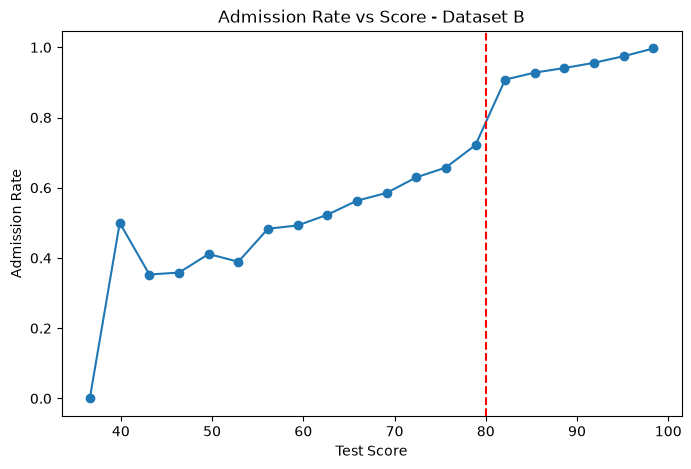

In [ ]:
# ------------------------------------------------------------
# Binned admission rate for Dataset B
# ------------------------------------------------------------

df_b["bin_80"] = pd.cut(
    df_b["X2"],
    bins=20
)

rates_b = df_b.groupby("bin_80")["Y2"].mean()

x_vals_b = [
    interval.mid
    for interval in rates_b.index
]

plt.figure(figsize=(8, 5))

plt.plot(
    x_vals_b,
    rates_b.values,
    marker="o"
)

plt.axvline(
    80,
    color="red",
    linestyle="--"
)

plt.xlabel("Test Score")
plt.ylabel("Admission Rate")
plt.title("Admission Rate vs Score - Dataset B")
plt.show()


In [37]:
# ------------------------------------------------------------
# RDD regression for Dataset A with cutoff 80
# ------------------------------------------------------------

df_a["treated_80"] = (df_a["X"] >= 80).astype(int)
df_a["running_80"] = df_a["X"] - 80

model_a_80 = smf.ols(
    "Y ~ running_80 + treated_80 + running_80:treated_80",
    data=df_a
).fit()

print(model_a_80.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     3300.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:16:23   Log-Likelihood:                -67412.
No. Observations:              100000   AIC:                         1.348e+05
Df Residuals:                   99996   BIC:                         1.349e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.30

In [38]:
# ------------------------------------------------------------
# RDD regression for Dataset B with cutoff 80
# ------------------------------------------------------------

df_b["treated_80"] = (df_b["X2"] >= 80).astype(int)
df_b["running_80"] = df_b["X2"] - 80

model_b_80 = smf.ols(
    "Y2 ~ running_80 + treated_80 + running_80:treated_80",
    data=df_b
).fit()

print(model_b_80.summary())


                            OLS Regression Results                            
Dep. Variable:                     Y2   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     6360.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:16:30   Log-Likelihood:                -45123.
No. Observations:              100000   AIC:                         9.025e+04
Df Residuals:                   99996   BIC:                         9.029e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.70

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


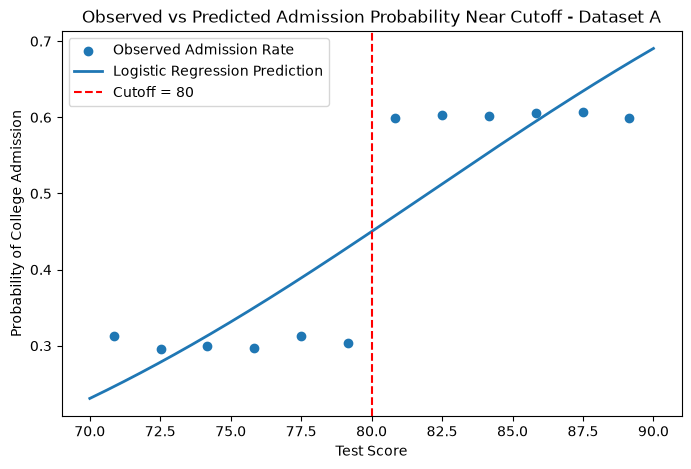

In [39]:
# ------------------------------------------------------------
# Reflection 4:
# Logistic regression predicted probability near cutoff 80
# Dataset A
# ------------------------------------------------------------

df_logit_a = pd.read_csv("homework_4.2.a.csv")

cutoff = 80
bandwidth = 10

local_logit_a = df_logit_a[
    (df_logit_a["X"] >= cutoff - bandwidth)
    &
    (df_logit_a["X"] <= cutoff + bandwidth)
].copy()

logit_a = LogisticRegression()

logit_a.fit(
    local_logit_a[["X"]],
    local_logit_a["Y"]
)

x_grid_a = np.linspace(
    local_logit_a["X"].min(),
    local_logit_a["X"].max(),
    300
).reshape(-1, 1)

predicted_probabilities_a = (
    logit_a.predict_proba(x_grid_a)[:, 1]
)

local_logit_a["score_bin"] = pd.cut(
    local_logit_a["X"],
    bins=12
)

binned_a = (
    local_logit_a
    .groupby("score_bin")
    .agg(
        avg_score=("X", "mean"),
        admission_rate=("Y", "mean")
    )
    .dropna()
)

plt.figure(figsize=(8, 5))

plt.scatter(
    binned_a["avg_score"],
    binned_a["admission_rate"],
    label="Observed Admission Rate"
)

plt.plot(
    x_grid_a.flatten(),
    predicted_probabilities_a,
    linewidth=2,
    label="Logistic Regression Prediction"
)

plt.axvline(
    cutoff,
    color="red",
    linestyle="--",
    label="Cutoff = 80"
)

plt.xlabel("Test Score")
plt.ylabel("Probability of College Admission")
plt.title("Observed vs Predicted Admission Probability Near Cutoff - Dataset A")
plt.legend()
plt.show()
